# Stabilizer Approach Experiment

This experiment aims to explore the difference in fidelity between different approaches for quantum error correction.

## Tasks:

- [ ] Test with Mirage decomposition of syndromes
- [ ] Add more physical assumptions to how long gates / measurements take to perform
- Test with different Topologies
    - [ ] Add functionality to experiment_run to allow remeasuring of qubits
    - [ ] Add functionality to circuits to allow remeasuring old ancilla to use in syndrome measurement
    - [ ] Determine reset time for ancilla to be reused after measurement
    
- Determine whether can use Dylan's gradient flow based evolution to determine any physical limits which might come up as future problems
- Determine how Mirage can be implemented properly with what code


In [1]:
# Import the compact ExperimentRunner and required libs
import os
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from quantum_logical.circuits import (
    partial_erasure_circuit,
)
from quantum_logical.experiment_runner import ExperimentRunner
from quantum_logical.gates import (
    hadamard_operator,
)
from quantum_logical.phase_circuits import (
    partial_phase_circuit,
)

runner = ExperimentRunner()


In [2]:
def base_three_to_base_ten(digits: List[int]) -> int:
    """Convert a list of base-3 digits to a base-10 integer."""
    return sum(d * (3 ** i) for i, d in enumerate(reversed(digits)))

In [6]:
def plot_results(trotter_dt: float, state_list: List[qt.Qobj], output_path: str, t1, t2) -> None:
    """Create and save diagnostic plots for a completed experiment.

    The function computes time-steps from `trotter_dt` and extracts marginal
    probabilities and fidelities from `state_list`. It writes three PNG files
    (`probabilities_plot.png`, `fidelities_plot.png`, `ancillary_probabilities_plot.png`) into
    `output_path` and also displays them via `matplotlib`.

    Args:
        trotter_dt: Time resolution used during simulation (used to label x-axis).
        state_list: Ordered list of `qutip.Qobj` states from the simulation.
        output_path: Directory where PNGs will be written (created if missing).

    Returns:
        None
    """
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    time_steps = np.linspace(0, trotter_dt * (len(state_list)), len(state_list))

    probabilities = [state.ptrace([0, 1, 2]).diag().real for state in state_list]
    probabilities = np.array(probabilities)

    #init_state = (
    #    qt.tensor(qt.basis(3, 0), qt.basis(3, 0), qt.basis(3, 0))
    #    + qt.tensor(qt.basis(3, 0), qt.basis(3, 2), qt.basis(3, 2))
    #    + qt.tensor(qt.basis(3, 2), qt.basis(3, 2), qt.basis(3, 0))
    #    + qt.tensor(qt.basis(3, 2), qt.basis(3, 0), qt.basis(3, 2))
    #) / 2.0

    plus_state = hadamard_operator(3) * qt.basis(3,0)
    init_state = qt.tensor(plus_state, plus_state, plus_state)
    fidelities = [qt.fidelity(state.ptrace([0, 1, 2]), init_state) for state in state_list]
    fidelities = np.array(fidelities)

    plt.figure(figsize=(10, 6))
    for i in range(27): # one 0 two 2, 222
        plt.plot(time_steps, probabilities[:, i], label=f"State |{np.base_repr(i, base=3)}>")
    plt.xlabel(r"Time Step ($\mu$s)")
    plt.ylabel("Probability")
    plt.title("State Probabilities Over Time")
    plt.legend()
    plt.savefig(f"{output_path}/probabilities_plot.png")
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(time_steps, fidelities, label="Fidelity")
    plt.xlabel(r"Time Step ($\mu$s)")
    plt.ylabel("Fidelities")
    plt.suptitle(f"Fidelity between |+++> Over Time with T1 = {t1:.1f}μs, T2 = {t2:.1f}μs")
    plt.title(f"Final Fidelity: {fidelities[-1]:.4f}")
    plt.legend()
    plt.savefig(f"{output_path}/fidelities_plot.png")
    plt.show()

    np.save(f"{output_path}/fidelity_array.npy", fidelities)

    probabilities = [state.ptrace([3]).diag().real for state in state_list]
    probabilities = np.array(probabilities)
    plt.figure(figsize=(10, 6))
    for i in [0, 1, 2]: # one 0 two 2, 222
        plt.plot(time_steps, probabilities[:, i], label=f"State {np.base_repr(i, base=3)}")
    plt.xlabel("Time Step")
    plt.ylabel("Probabilities")
    plt.title("Ancillary Probabilities Over Time")
    plt.legend()
    plt.savefig(f"{output_path}/ancillary_probabilities_plot.png")
    plt.show()

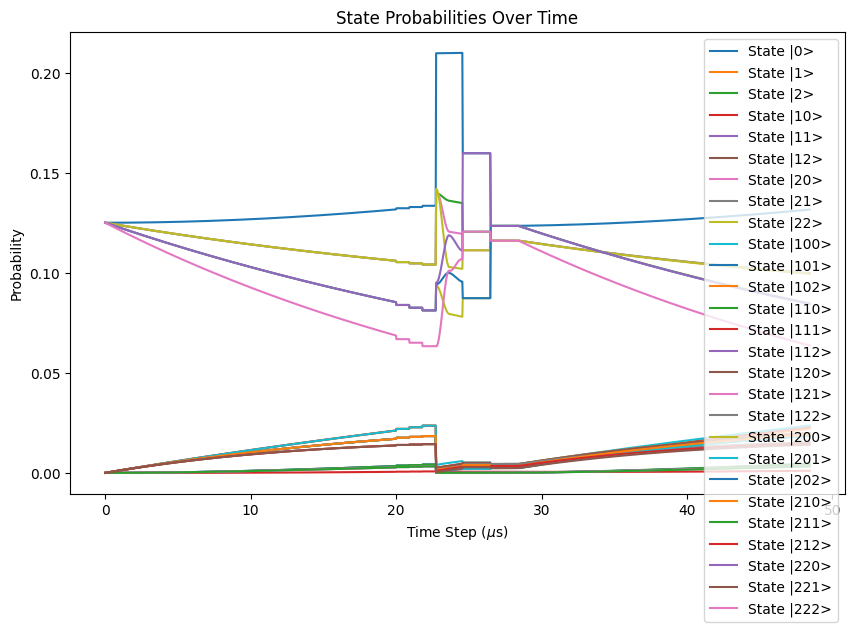

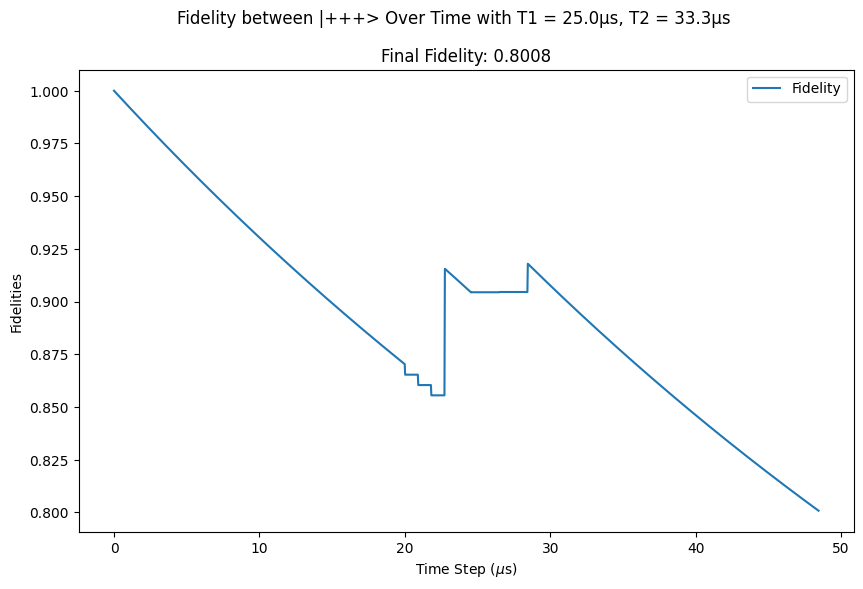

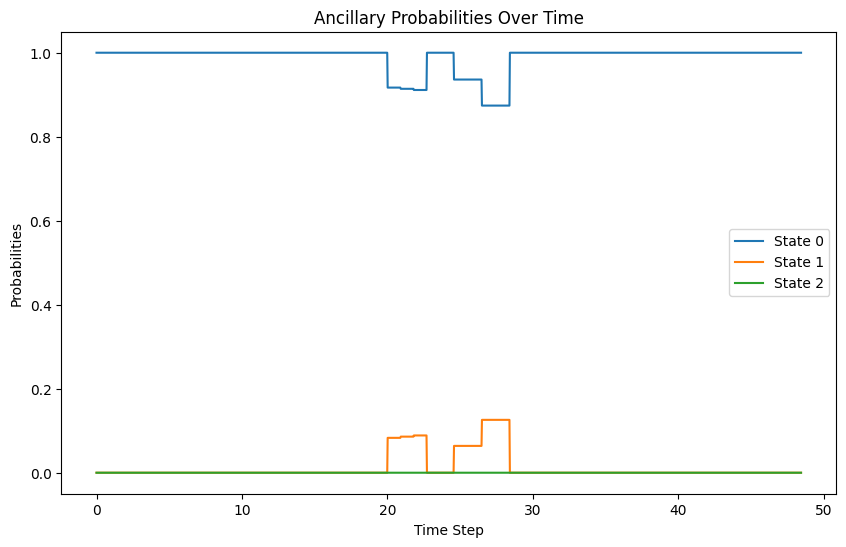

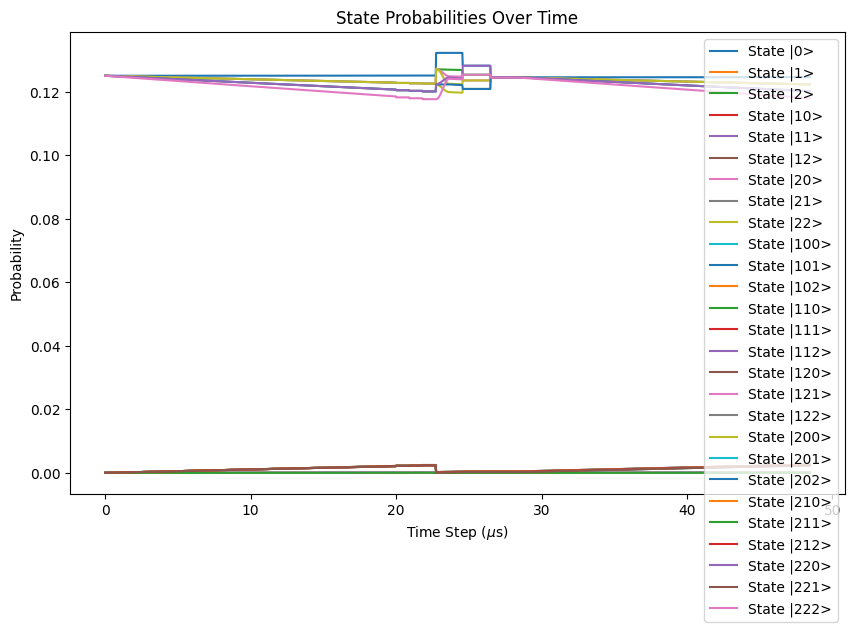

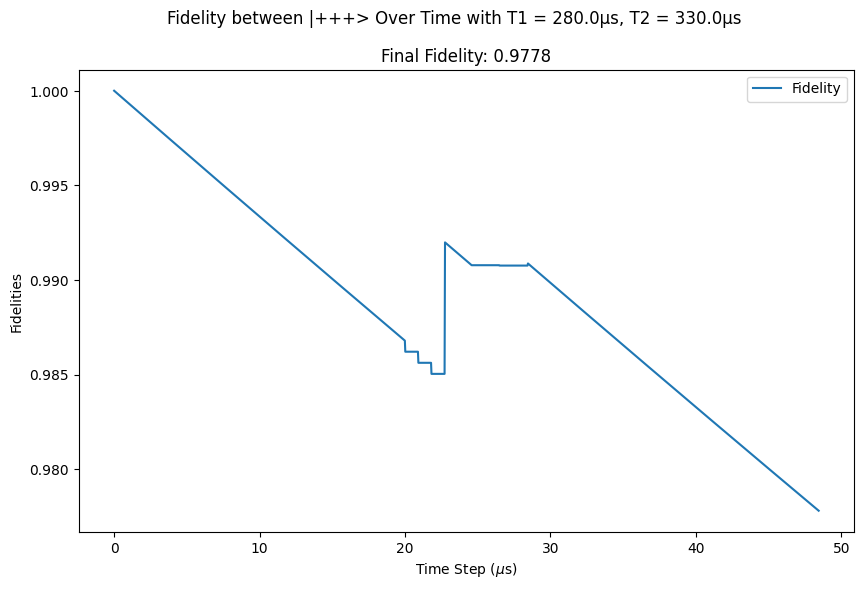

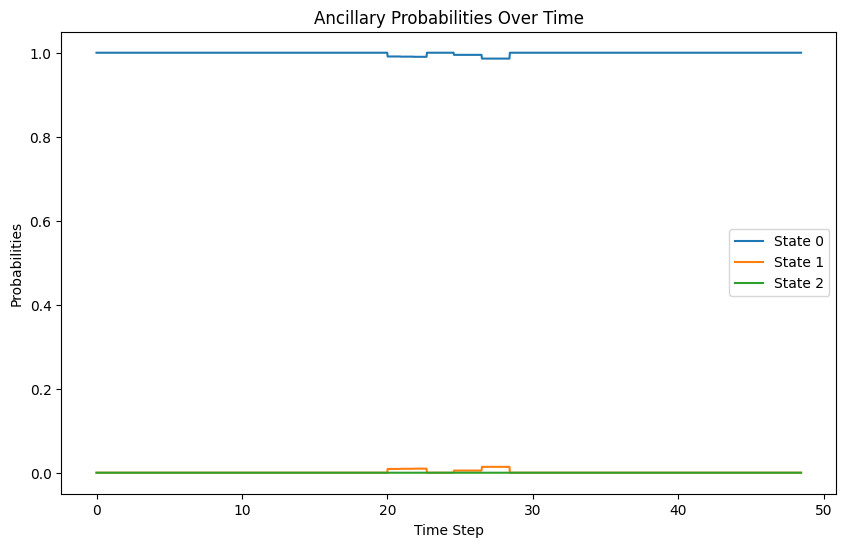

In [10]:
# Parameters (kept concise in the notebook)
iterations = 2
t1_list = [25, 280]
t2_list = [33.3, 330]
trotter_dt = .03
cnot_time = .9
single_qudit_time = .03

# Individual superpositions
plus_state = hadamard_operator(3) * qt.basis(3,0)
minus_state = hadamard_operator(3) * qt.basis(3,2)

hada_layer = qt.tensor(hadamard_operator(3), hadamard_operator(3), hadamard_operator(3))
# Prepare initial logical state
logical_psi_0 = (qt.tensor(plus_state, plus_state, plus_state))  # Small  phase error from |+++>
total_psi_0 = qt.tensor(logical_psi_0, qt.basis(3,0))  # ancillas in |0>
rho_0 = total_psi_0 * total_psi_0.dag()

# Create runner and trotterizer, then run experiment with a list of setups
for i in range(iterations):
    trotterizer = runner.generate_trotterizer(trotter_dt, t1_list[i], t2_list[i], 3, 4)
    setups = [
              
              partial_erasure_circuit(single_qudit_time, cnot_time, num_ancillae=1, target_state=0),
              partial_erasure_circuit(single_qudit_time, cnot_time, num_ancillae=1, target_state=1),
              partial_erasure_circuit(single_qudit_time, cnot_time, num_ancillae=1, target_state=2),
              partial_phase_circuit(single_qudit_time, cnot_time, target_state=0),
              partial_phase_circuit(single_qudit_time, cnot_time, target_state=1),
              ]
    state_list = runner.experiment_partial_run(trotterizer, rho_0, setups)
    plot_results(trotter_dt, state_list, f"PPEEE/t1_{t1_list[i]:.1f}_t2_{t2_list[i]:.1f}", t1_list[i], t2_list[i])